<a href="https://colab.research.google.com/github/abmalek2560-cmd/smart-farming-dinajpur-crop-selection/blob/main/ET0_Prediction_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
import pandas as pd
import numpy as np

# 1. Drive Mount
drive.mount('/content/drive')

# 2.
file_path = '/content/drive/MyDrive/power_data.csv'

# 3. skiprows=14
try:
    df = pd.read_csv(file_path, skiprows=14, on_bad_lines='skip')
    print("--- Data Successfully Loaded! ---")
    print("Columns found:", df.columns.tolist())
    display(df.head())
except Exception as e:
    print("Error loading file:", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Data Successfully Loaded! ---
Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']


,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,ALLSKY_SFC_SW_DWN,2010,13.49,17.19,19.61,18.95,19.48,15.05,17.43,16.22,16.64,16.36,14.58,13.60,16.55
1,ALLSKY_SFC_SW_DWN,2011,11.81,16.57,18.99,20.43,19.17,17.37,16.14,16.34,16.62,17.88,14.85,11.56,16.47
2,ALLSKY_SFC_SW_DWN,2012,12.00,17.47,20.66,20.68,20.62,15.13,15.71,17.75,15.07,17.82,15.02,10.70,16.55
3,ALLSKY_SFC_SW_DWN,2013,14.03,17.38,20.41,19.51,16.88,18.20,17.87,16.20,17.46,14.54,16.09,12.33,16.72
4,ALLSKY_SFC_SW_DWN,2014,12.17,15.35,19.84,23.06,19.92,15.49,17.28,15.01,15.60,17.91,14.93,12.23,16.57


In [13]:
import pandas as pd
import numpy as np

# ১. Data Transformation (Monthly Data ke Structure kora)
# Parameter mapping
param_map = {
    'ALLSKY_SFC_SW_DWN': 'Rs',
    'T2M_MAX': 'Tmax',
    'T2M_MIN': 'Tmin',
    'T2M': 'Tmean',
    'RH2M': 'RH',
    'WS2M': 'u2'
}

# Transform long format to month-wise structured data
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

records = []
years = df['YEAR'].unique()

for yr in years:
    df_year = df[df['YEAR'] == yr]
    for m_idx, m_name in enumerate(months, 1):
        row_dict = {'YEAR': yr, 'MONTH': m_idx}
        for orig_p, new_p in param_map.items():
            val = df_year[df_year['PARAMETER'] == orig_p][m_name].values
            if len(val) > 0:
                row_dict[new_p] = val[0]
            else:
                row_dict[new_p] = np.nan
        records.append(row_dict)

df_monthly = pd.DataFrame(records).dropna()

# ২. FAO-56 Penman-Monteith ET0 Calculation Function
def calculate_monthly_eto(row):
    Tmax = row['Tmax']
    Tmin = row['Tmin']
    Tmean = row['Tmean']
    RH = row['RH']
    Rs = row['Rs']   # MJ/m2/day
    u2 = row['u2']   # m/s

    # Elevation ~ 30m (Rangpur)
    P = 101.3 * (((293 - 0.0065 * 30) / 293) ** 5.26)
    gamma = 0.000665 * P

    # Vapor pressure
    e_Tmax = 0.6108 * np.exp((17.27 * Tmax) / (Tmax + 237.3))
    e_Tmin = 0.6108 * np.exp((17.27 * Tmin) / (Tmin + 237.3))
    es = (e_Tmax + e_Tmin) / 2
    ea = (RH / 100.0) * es

    # Slope curve
    delta = (4098 * (0.6108 * np.exp((17.27 * Tmean) / (Tmean + 237.3)))) / ((Tmean + 237.3) ** 2)

    # Net Radiation (Rn)
    Rns = (1 - 0.23) * Rs
    sigma = 4.903e-9
    Tmax_K = Tmax + 273.16
    Tmin_K = Tmin + 273.16
    Rnl = sigma * (((Tmax_K**4) + (Tmin_K**4)) / 2) * (0.34 - 0.14 * np.sqrt(ea)) * 0.8
    Rn = Rns - Rnl

    # Penman-Monteith Equation
    num = 0.408 * delta * Rn + gamma * (900 / (Tmean + 273)) * u2 * (es - ea)
    den = delta + gamma * (1 + 0.34 * u2)

    return num / den

# ET0 calculate kora
df_monthly['ET0'] = df_monthly.apply(calculate_monthly_eto, axis=1)

print("--- Monthly ET0 Calculation Completed! ---")
display(df_monthly[['YEAR', 'MONTH', 'Tmax', 'Tmin', 'Tmean', 'RH', 'Rs', 'u2', 'ET0']].head(12))

--- Monthly ET0 Calculation Completed! ---


,YEAR,MONTH,Tmax,Tmin,Tmean,RH,Rs,u2,ET0
0,2010,1,26.80,7.47,16.38,66.73,13.49,1.59,2.374940
1,2010,2,31.37,10.13,20.38,49.28,17.19,1.77,4.035718
2,2010,3,40.04,15.86,27.68,37.01,19.61,2.04,6.262870
3,2010,4,42.26,22.48,31.65,47.44,18.95,2.27,6.414414
4,2010,5,41.25,23.95,30.64,67.48,19.48,2.27,5.620020
5,2010,6,37.47,25.72,29.41,84.39,15.05,2.57,3.657125
6,2010,7,33.61,25.40,28.96,86.51,17.43,2.41,3.723725
7,2010,8,34.13,25.45,28.93,85.26,16.22,1.92,3.500507
8,2010,9,32.32,22.44,27.84,86.74,16.64,1.58,3.275680
9,2010,10,31.97,18.12,25.54,85.78,16.36,1.94,3.078716


Features Shape: (180, 6)
Target Shape: (180,)


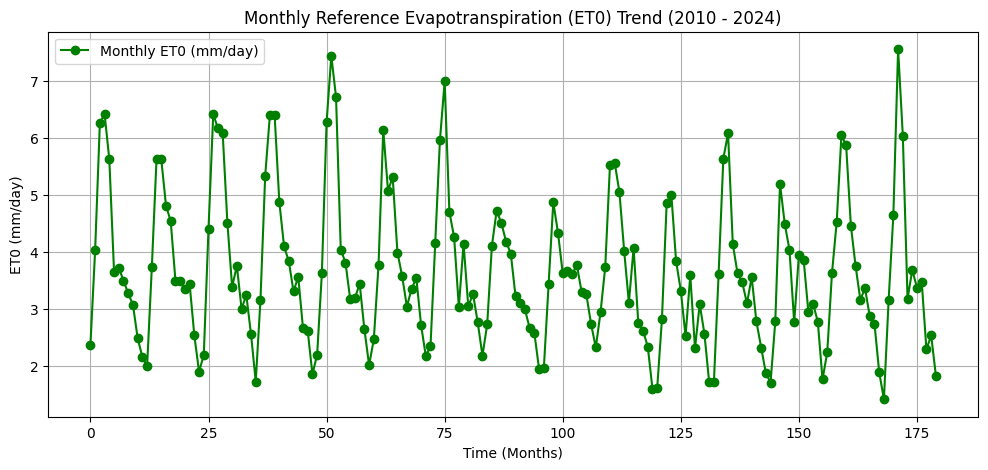


Processed data file successfully saved: /content/drive/MyDrive/calculated_monthly_eto.csv


In [22]:
import matplotlib.pyplot as plt

# 1. Feature (X) and Target (y)
X = df_monthly[['Tmax', 'Tmin', 'Tmean', 'RH', 'Rs', 'u2']]
y = df_monthly['ET0']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# ২. Monthly ET0 Trend Visualisation
plt.figure(figsize=(12, 5))
plt.plot(df_monthly['ET0'], label='Monthly ET0 (mm/day)', color='green', marker='o')
plt.title('Monthly Reference Evapotranspiration (ET0) Trend (2010 - 2024)')
plt.xlabel('Time (Months)')
plt.ylabel('ET0 (mm/day)')
plt.grid(True)
plt.legend()
plt.show()

# 3. Save the processed data as a CSV file to Drive
output_path = '/content/drive/MyDrive/calculated_monthly_eto.csv'
df_monthly.to_csv(output_path, index=False)
print(f"\nProcessed data file successfully saved: {output_path}")

Training Samples: 144, Testing Samples: 36

--- Random Forest Performance ---
R² Score: 0.9649
RMSE:     0.2295 mm/day
MAE:      0.1638 mm/day

--- XGBoost Performance ---
R² Score: 0.9703
RMSE:     0.2113 mm/day
MAE:      0.1516 mm/day


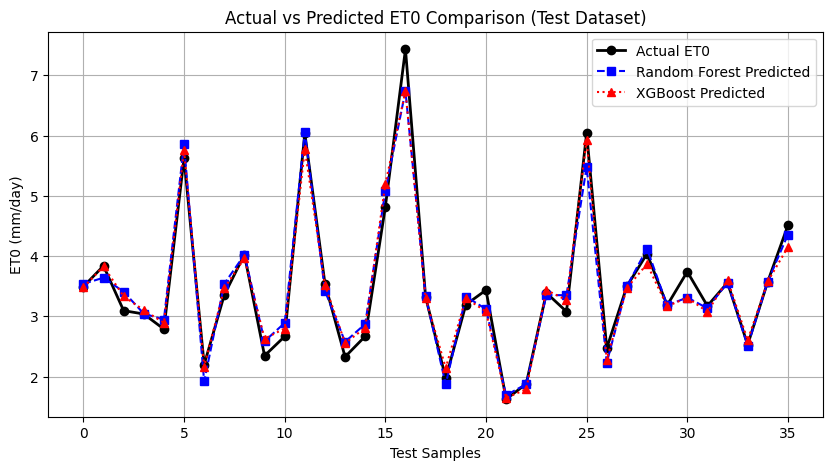

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

 # 1. Data Transformation: Reshape monthly parameters into structured format
df_final = pd.read_csv('/content/drive/MyDrive/calculated_monthly_eto.csv')

# Features (X) & Target (y)
X = df_final[['Tmax', 'Tmin', 'Tmean', 'RH', 'Rs', 'u2']]
y = df_final['ET0']

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}")

# 3. Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 4. XGBoost Regressor Model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 5. Performance Metrics Evaluation Function
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n--- {name} Performance ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE:     {rmse:.4f} mm/day")
    print(f"MAE:      {mae:.4f} mm/day")

evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

# 6. Actual vs Predicted Plot
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual ET0', color='black', linewidth=2, marker='o')
plt.plot(rf_pred, label='Random Forest Predicted', color='blue', linestyle='--', marker='s')
plt.plot(xgb_pred, label='XGBoost Predicted', color='red', linestyle=':', marker='^')
plt.title('Actual vs Predicted ET0 Comparison (Test Dataset)')
plt.xlabel('Test Samples')
plt.ylabel('ET0 (mm/day)')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step
--- LSTM Model Performance ---
R² Score: 0.7696
RMSE:     0.6495 mm/day
MAE:      0.4821 mm/day


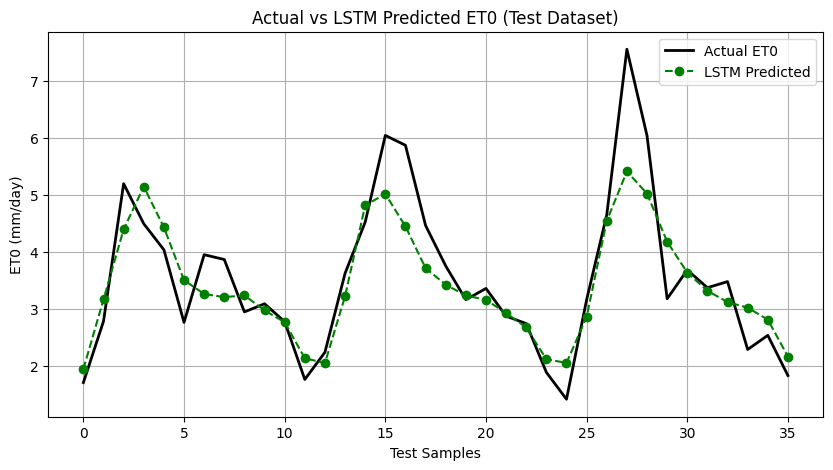

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import tensorflow as np_tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Load processed data.
df_final = pd.read_csv('/content/drive/MyDrive/calculated_monthly_eto.csv')

# Features (X) & Target (y)
X = df_final[['Tmax', 'Tmin', 'Tmean', 'RH', 'Rs', 'u2']].values
y = df_final['ET0'].values

# 2. Scaling (MinMaxScaler) - Deep Learning
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# 3. Time-step (Sequencing)
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 3
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps=TIME_STEPS)

# Train-Test Split (80% Train, 20% Test)
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

# 4. LSTM Model Architecture
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 5. Model Training
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)

# 6. Prediction & Rescaling
y_pred_scaled = model.predict(X_test_seq)
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# 7. Metrics Calculation
r2_lstm = r2_score(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)

print("--- LSTM Model Performance ---")
print(f"R² Score: {r2_lstm:.4f}")
print(f"RMSE:     {rmse_lstm:.4f} mm/day")
print(f"MAE:      {mae_lstm:.4f} mm/day")

# 8. Plotting
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label='Actual ET0', color='black', linewidth=2)
plt.plot(y_pred_lstm, label='LSTM Predicted', color='green', linestyle='--', marker='o')
plt.title('Actual vs LSTM Predicted ET0 (Test Dataset)')
plt.xlabel('Test Samples')
plt.ylabel('ET0 (mm/day)')
plt.legend()
plt.grid(True)
plt.show()

=================== MODEL COMPARISON SUMMARY ===================


,Model Name,R² Score,RMSE (mm/day),MAE (mm/day)
0,XGBoost Regressor,0.970264,0.211322,0.151573
1,Random Forest,0.964913,0.229548,0.163751
2,LSTM (Deep Learning),0.769557,0.649522,0.482098


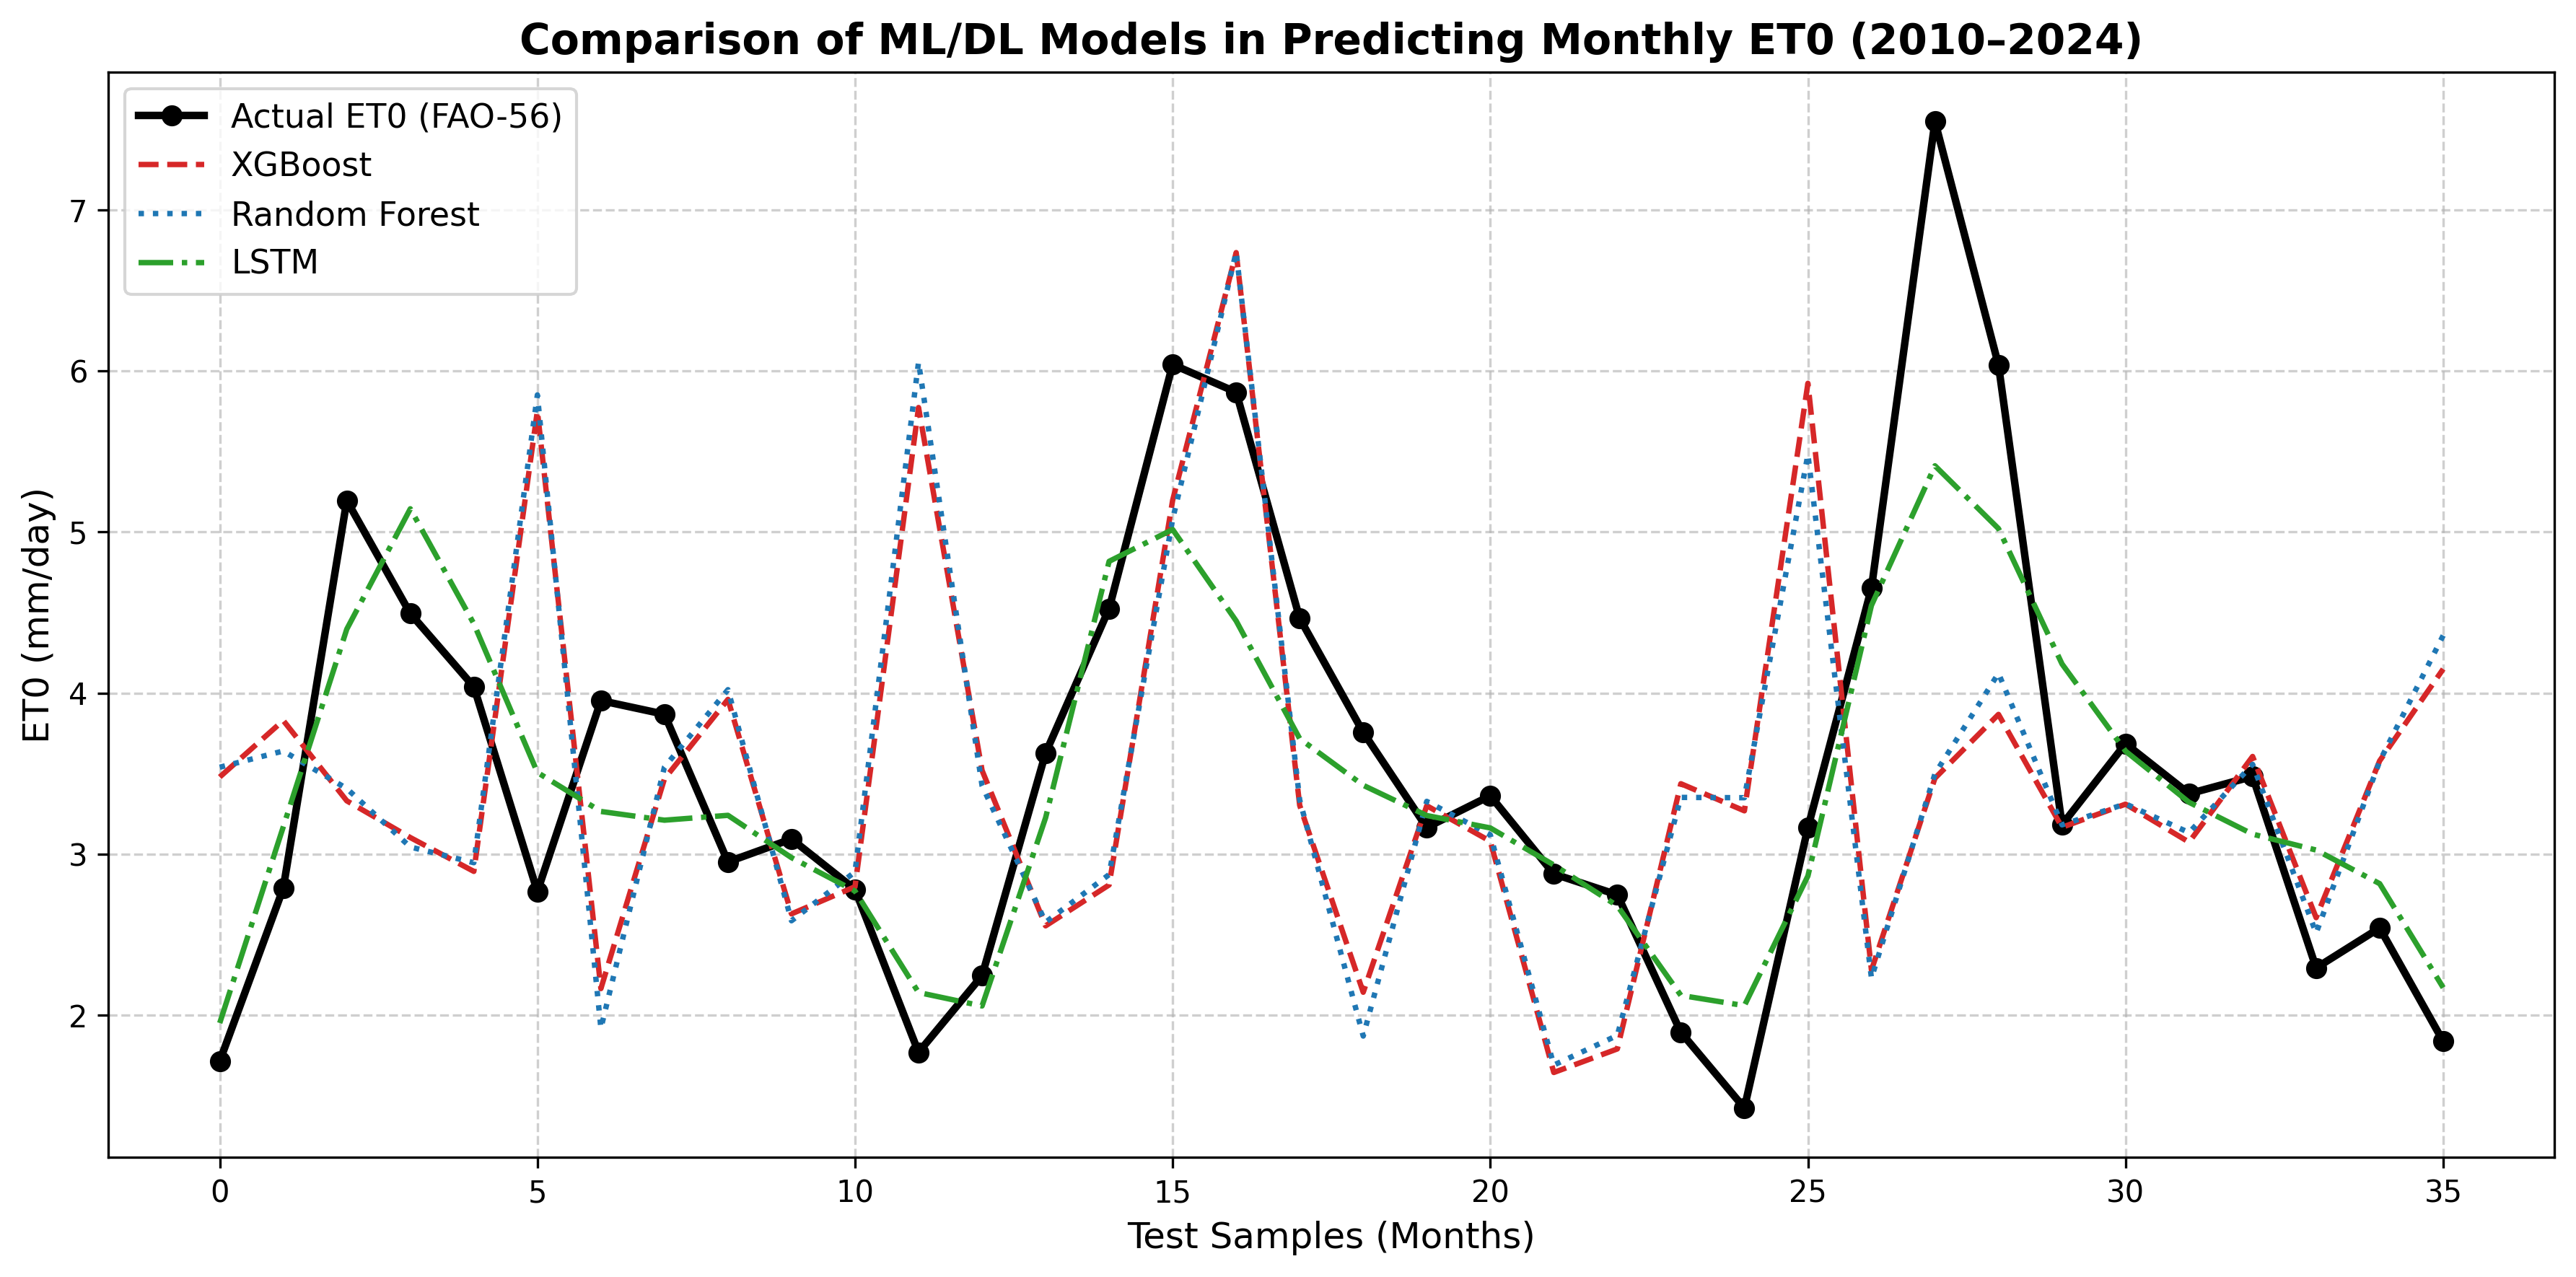


HD quality plot successfully saved to Drive: ET0_Model_Comparison_Plot.png


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Final Summary Data Table
data = {
    'Model Name': ['XGBoost Regressor', 'Random Forest', 'LSTM (Deep Learning)'],
    'R² Score': [r2_score(y_test, xgb_pred), r2_score(y_test, rf_pred), r2_lstm],
    'RMSE (mm/day)': [np.sqrt(mean_squared_error(y_test, xgb_pred)), np.sqrt(mean_squared_error(y_test, rf_pred)), rmse_lstm],
    'MAE (mm/day)': [mean_absolute_error(y_test, xgb_pred), mean_absolute_error(y_test, rf_pred), mae_lstm]
}

summary_df = pd.DataFrame(data)
print("=================== MODEL COMPARISON SUMMARY ===================")
display(summary_df)

# 2. Combined Comparative Graph
plt.figure(figsize=(12, 6), dpi=300)

# Actual Data
plt.plot(y_test_actual, label='Actual ET0 (FAO-56)', color='black', linewidth=2.5, marker='o')

# Predictions
plt.plot(xgb_pred[-len(y_test_actual):], label='XGBoost', color='#d62728', linestyle='--', linewidth=1.8)
plt.plot(rf_pred[-len(y_test_actual):], label='Random Forest', color='#1f77b4', linestyle=':', linewidth=1.8)
plt.plot(y_pred_lstm, label='LSTM', color='#2ca02c', linestyle='-.', linewidth=1.8)

plt.title('Comparison of ML/DL Models in Predicting Monthly ET0 (2010–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Test Samples (Months)', fontsize=12)
plt.ylabel('ET0 (mm/day)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Export high-resolution figure to Google Drive
plt.savefig('/content/drive/MyDrive/ET0_Model_Comparison_Plot.png', dpi=300)
plt.show()
print("\nHD quality plot successfully saved to Drive: ET0_Model_Comparison_Plot.png")